In [2]:
# ============================================================================
# 0. FORZAR USO DE GPU EN KAGGLE
# ============================================================================

import os
import tensorflow as tf

print("=" * 80)
print("🎮 CONFIGURACIÓN DE GPU")
print("=" * 80)

# 1. Verificar GPUs disponibles
gpus = tf.config.list_physical_devices('GPU')
print(f"\n📊 GPUs detectadas: {len(gpus)}")

if len(gpus) == 0:
    print("❌ NO SE DETECTÓ GPU")
    print("\n🔧 SOLUCIÓN:")
    print("   1. Ve a Settings (lado derecho)")
    print("   2. Accelerator > GPU T4 x2")
    print("   3. Click en 'Save'")
    print("   4. REINICIA el kernel (Session > Restart)")
    raise SystemExit("⚠️ Configura GPU y reinicia el kernel")

# 2. Mostrar GPUs
for i, gpu in enumerate(gpus):
    print(f"   ✅ GPU {i}: {gpu.name}")
    
# 3. Configurar crecimiento de memoria (CRÍTICO)
try:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("\n✅ Memoria GPU configurada (crecimiento dinámico)")
except RuntimeError as e:
    print(f"⚠️ Advertencia al configurar memoria: {e}")

# 4. Forzar TensorFlow a usar GPU
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1'  # Usar ambas GPUs
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ['TF_GPU_THREAD_MODE'] = 'gpu_private'

# 5. Test rápido de GPU
print("\n🧪 Test de GPU:")
with tf.device('/GPU:0'):
    a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
    b = tf.constant([[1.0, 2.0], [3.0, 4.0]])
    c = tf.matmul(a, b)
    print(f"   ✅ Operación exitosa en GPU")

# 6. Mostrar dispositivo por defecto
print(f"\n💡 Dispositivo por defecto: {tf.test.gpu_device_name()}")

print("\n" + "=" * 80)
print("✅ GPU LISTA PARA USAR")
print("=" * 80)

2025-10-27 14:09:36.911370: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761574177.113587      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761574177.170418      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


🎮 CONFIGURACIÓN DE GPU

📊 GPUs detectadas: 2
   ✅ GPU 0: /physical_device:GPU:0
   ✅ GPU 1: /physical_device:GPU:1

✅ Memoria GPU configurada (crecimiento dinámico)

🧪 Test de GPU:
   ✅ Operación exitosa en GPU

💡 Dispositivo por defecto: /device:GPU:0

✅ GPU LISTA PARA USAR


I0000 00:00:1761574189.329031      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1761574189.329941      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1761574189.464900      37 gpu_device.cc:2022] Created device /device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1761574189.465380      37 gpu_device.cc:2022] Created device /device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:
# ============================================================================
# 1. IMPORTACIONES
# ============================================================================

import gc
import numpy as np
import cv2
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# ============================================================================
# 2. CARGAR DATASET PREPROCESADO DESDE GOOGLE DRIVE (KAGGLE)
# ============================================================================


import zipfile
import pickle
import gdown

# Configuración: usa el enlace correcto de Google Drive
DRIVE_URL = 'https://drive.google.com/uc?id=1ReMjp7GNUz1cm2o-V8nDDdtAO9shnUtE'  # ✅ Cambia por tu ID
ZIP_PATH = '/kaggle/working/desayuno_preprocessed_archive.zip'  # ✅ Kaggle
DATASET_DIR = '/kaggle/working/desayuno_preprocessed'  # ✅ Kaggle

# Descargar desde Google Drive
print("Descargando ZIP desde Google Drive...")
try:
    gdown.download(DRIVE_URL, ZIP_PATH, quiet=False)
except Exception as e:
    print(f"Error al descargar: {e}")
    print("Verifica el enlace de Google Drive o sube el ZIP manualmente")
    raise

# Verificar tamaño del archivo
if os.path.getsize(ZIP_PATH) < 1000000:  # Menos de 1 MB
    print("Error: El archivo descargado es demasiado pequeño, probablemente no es el ZIP correcto")
    raise ValueError("Archivo descargado no válido")

# Descomprimir ZIP
try:
    os.makedirs(DATASET_DIR, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(DATASET_DIR)
    print(f"Descomprimido en: {DATASET_DIR}")
except zipfile.BadZipFile:
    print("Error: El archivo descargado no es un ZIP válido")
    print("Verifica que el archivo en Google Drive sea correcto (170.56 MB)")
    raise

# Cargar pickle
PKL_PATH = os.path.join(DATASET_DIR, 'food101_desayuno_preprocessed.pkl')
with open(PKL_PATH, 'rb') as f:
    data = pickle.load(f)

npz_files = data['npz_files']
DESAYUNO_CLASSES = data['class_names']  # ✅ Renombrado para compatibilidad

# Cargar datos
X, y = [], []
for npz_file in npz_files:
    with np.load(os.path.join(DATASET_DIR, npz_file)) as npz:
        X.append(npz['X'])
        y.append(npz['y'])

X = np.concatenate(X, axis=0)
y = np.concatenate(y, axis=0)

print(f"✅ Dataset cargado: Imágenes {X.shape}, Etiquetas {y.shape}")
print(f"✅ Clases: {len(DESAYUNO_CLASSES)}")

# Detectar TARGET_SIZE automáticamente
if X.ndim == 4:
    TARGET_SIZE = X.shape[1]
    print(f"✅ TARGET_SIZE detectado: {TARGET_SIZE}x{TARGET_SIZE}")
else:
    print(f"⚠️ Advertencia: X tiene forma {X.shape}, verifica si necesitas reshape")

Descargando ZIP desde Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=1ReMjp7GNUz1cm2o-V8nDDdtAO9shnUtE
From (redirected): https://drive.google.com/uc?id=1ReMjp7GNUz1cm2o-V8nDDdtAO9shnUtE&confirm=t&uuid=0feeb22d-9561-4874-8376-0afd0b30840c
To: /kaggle/working/desayuno_preprocessed_archive.zip
100%|██████████| 3.23G/3.23G [00:33<00:00, 96.8MB/s]


Descomprimido en: /kaggle/working/desayuno_preprocessed
✅ Dataset cargado: Imágenes (20760, 224, 224, 3), Etiquetas (20760,)
✅ Clases: 21
✅ TARGET_SIZE detectado: 224x224


In [5]:
# ============================================================================
# 3. SPLIT TRAIN/TEST
# ============================================================================

print("\n[PASO 3] Dividiendo dataset (80/20)...")
print("-" * 80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"✅ Split completado:")
print(f"   • Train: {X_train.shape[0]:,} imágenes")
print(f"   • Test:  {X_test.shape[0]:,} imágenes")

# Liberar memoria
del X, y
gc.collect()



[PASO 3] Dividiendo dataset (80/20)...
--------------------------------------------------------------------------------
✅ Split completado:
   • Train: 16,608 imágenes
   • Test:  4,152 imágenes


733

In [6]:
# ============================================================================
# 4. FEATURE EXTRACTION CON RESNET50 (FORZANDO GPU)
# ============================================================================

print("\n[PASO 4] Extrayendo features con ResNet50...")
print("-" * 80)


from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input


# ✅ FORZAR que todo se ejecute en GPU
print("🎮 Forzando uso de GPU...")

# Cargar ResNet50 EN GPU
print("🔧 Cargando ResNet50 en GPU...")
with tf.device('/GPU:0'):  # ✅ FORZAR GPU 0
    feature_extractor = ResNet50(
        weights='imagenet',
        include_top=False,
        pooling='avg',
        input_shape=(224, 224, 3)
    )
    # Compilar modelo para asegurar que esté en GPU
    feature_extractor.compile()

print(f"✅ Modelo cargado en GPU")
print(f"   • Features dim: {feature_extractor.output_shape[1]}")

# Verificar que el modelo está en GPU
print(f"   • Dispositivo: {feature_extractor.layers[0].dtype_policy.compute_dtype}")

# Función optimizada CON GPU FORZADA
def extract_features_batch(images, batch_size=64):  # ✅ Batch más grande con GPU
    n_samples = len(images)
    n_batches = (n_samples + batch_size - 1) // batch_size
    features_list = []

    print(f"📊 Procesando {n_samples} imágenes en {n_batches} batches")
    print(f"   • Batch size: {batch_size}")
    print(f"   • Usando: GPU:0")
    
    for i in tqdm(range(n_batches), desc="🎮 GPU Extraction"):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, n_samples)
        batch = images[start_idx:end_idx]

        # Preprocesar
        batch_preprocessed = preprocess_input(batch * 255.0)
        
        # ✅ FORZAR ejecución en GPU
        with tf.device('/GPU:0'):
            batch_features = feature_extractor.predict(
                batch_preprocessed, 
                verbose=0,
                batch_size=batch_size  # ✅ Asegurar batch correcto
            )
        
        features_list.append(batch_features)

        # Liberar memoria cada 20 batches
        if i % 20 == 0 and i > 0:
            gc.collect()
            
            # Mostrar progreso
            if i % 50 == 0:
                progress_pct = (i / n_batches) * 100
                print(f"      Progress: {progress_pct:.1f}% ({i}/{n_batches} batches)")

    return np.vstack(features_list)

# Medir tiempo de extracción
import time

print("\n🔄 Extrayendo features de TRAIN...")
start_time = time.time()
X_train_features = extract_features_batch(X_train, batch_size=64)
train_time = time.time() - start_time

print(f"   ✅ Completado en {train_time:.1f}s ({train_time/60:.1f} min)")
print(f"   • Velocidad: {len(X_train)/train_time:.1f} imágenes/seg")

print("\n🔄 Extrayendo features de TEST...")
start_time = time.time()
X_test_features = extract_features_batch(X_test, batch_size=64)
test_time = time.time() - start_time

print(f"   ✅ Completado en {test_time:.1f}s ({test_time/60:.1f} min)")
print(f"   • Velocidad: {len(X_test)/test_time:.1f} imágenes/seg")

print(f"\n✅ Features extraídas:")
print(f"   • Train: {X_train_features.shape}")
print(f"   • Test:  {X_test_features.shape}")

# Verificación de velocidad
total_time = train_time + test_time
total_images = len(X_train) + len(X_test)
images_per_sec = total_images / total_time

print(f"\n📊 ESTADÍSTICAS:")
print(f"   • Tiempo total: {total_time/60:.1f} min")
print(f"   • Imágenes procesadas: {total_images:,}")
print(f"   • Velocidad: {images_per_sec:.1f} img/s")

if images_per_sec < 20:
    print("\n⚠️ ADVERTENCIA: Velocidad baja (<20 img/s)")
    print("   Puede estar usando CPU en lugar de GPU")
    print("   Velocidad esperada con GPU: 50-150 img/s")
else:
    print("\n✅ Velocidad correcta - usando GPU")

# Liberar imágenes originales
del X_train, X_test
gc.collect()

print("\n" + "=" * 80)
print("✅ PARTE 4 COMPLETADA")
print("=" * 80)






[PASO 4] Extrayendo features con ResNet50...
--------------------------------------------------------------------------------
🎮 Forzando uso de GPU...
🔧 Cargando ResNet50 en GPU...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Modelo cargado en GPU
   • Features dim: 2048
   • Dispositivo: float32

🔄 Extrayendo features de TRAIN...
📊 Procesando 16608 imágenes en 260 batches
   • Batch size: 64
   • Usando: GPU:0


🎮 GPU Extraction:   0%|          | 0/260 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1761574295.596390      98 service.cc:148] XLA service 0x7e542424c830 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761574295.597282      98 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1761574295.597306      98 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1761574296.252983      98 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1761574302.289785      98 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
🎮 GPU Extraction:  39%|███▉      | 101/260 [01:13<01:52,  1.41it/s]

      Progress: 38.5% (100/260 batches)


🎮 GPU Extraction:  77%|███████▋  | 201/260 [02:17<00:42,  1.39it/s]

      Progress: 76.9% (200/260 batches)


🎮 GPU Extraction: 100%|██████████| 260/260 [03:01<00:00,  1.43it/s]


   ✅ Completado en 181.9s (3.0 min)
   • Velocidad: 91.3 imágenes/seg

🔄 Extrayendo features de TEST...
📊 Procesando 4152 imágenes en 65 batches
   • Batch size: 64
   • Usando: GPU:0


🎮 GPU Extraction: 100%|██████████| 65/65 [00:47<00:00,  1.38it/s]


   ✅ Completado en 47.2s (0.8 min)
   • Velocidad: 88.0 imágenes/seg

✅ Features extraídas:
   • Train: (16608, 2048)
   • Test:  (4152, 2048)

📊 ESTADÍSTICAS:
   • Tiempo total: 3.8 min
   • Imágenes procesadas: 20,760
   • Velocidad: 90.6 img/s

✅ Velocidad correcta - usando GPU

✅ PARTE 4 COMPLETADA


In [7]:
# ============================================================================
# 5. ENTRENAR LIGHTGBM
# ============================================================================

print("\n[PASO 5] Entrenando LightGBM...")
print("-" * 80)

# Normalizar features
print("📊 Normalizando features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled = scaler.transform(X_test_features)

# Hiperparámetros conservadores
lgb_params = {
    'objective': 'multiclass',
    'num_class': len(DESAYUNO_CLASSES),
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 50,
    'max_depth': 10,
    'learning_rate': 0.03,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_child_samples': 30,
    'reg_alpha': 0.3,
    'reg_lambda': 0.3,
    'verbose': -1,
    'random_state': 42,
    'force_col_wise': True
}

print(f"⚙️ Hiperparámetros:")
for key, value in lgb_params.items():
    print(f"   {key:25s}: {value}")

# Crear datasets
print("\n📦 Creando datasets LightGBM...")
train_data = lgb.Dataset(X_train_scaled, label=y_train)
test_data = lgb.Dataset(X_test_scaled, label=y_test, reference=train_data)

# Entrenar
print("\n🚀 Entrenando modelo...")
evals_result = {}

model = lgb.train(
    lgb_params,
    train_data,
    num_boost_round=500,
    valid_sets=[train_data, test_data],
    valid_names=['train', 'test'],
    callbacks=[
        lgb.log_evaluation(period=50),
        lgb.early_stopping(stopping_rounds=80),
        lgb.record_evaluation(evals_result)
    ]
)

print(f"\n✅ Entrenamiento completado")
print(f"   • Mejor iteración: {model.best_iteration}")
print(f"   • Train loss: {evals_result['train']['multi_logloss'][-1]:.4f}")
print(f"   • Test loss:  {evals_result['test']['multi_logloss'][-1]:.4f}")
print(f"   • Diferencia: {abs(evals_result['test']['multi_logloss'][-1] - evals_result['train']['multi_logloss'][-1]):.4f}")




[PASO 5] Entrenando LightGBM...
--------------------------------------------------------------------------------
📊 Normalizando features...
⚙️ Hiperparámetros:
   objective                : multiclass
   num_class                : 21
   metric                   : multi_logloss
   boosting_type            : gbdt
   num_leaves               : 50
   max_depth                : 10
   learning_rate            : 0.03
   feature_fraction         : 0.8
   bagging_fraction         : 0.8
   bagging_freq             : 5
   min_child_samples        : 30
   reg_alpha                : 0.3
   reg_lambda               : 0.3
   verbose                  : -1
   random_state             : 42
   force_col_wise           : True

📦 Creando datasets LightGBM...

🚀 Entrenando modelo...
Training until validation scores don't improve for 80 rounds
[50]	train's multi_logloss: 0.67978	test's multi_logloss: 1.65978
[100]	train's multi_logloss: 0.228264	test's multi_logloss: 1.38049
[150]	train's multi_logloss: 0.0

In [8]:
# ============================================================================
# 6. EVALUACIÓN
# ============================================================================

print("\n[PASO 6] Evaluando modelo...")
print("-" * 80)

# Predicciones
y_pred_proba = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_proba, axis=1)

# Métricas
accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f"\n🎯 RESULTADOS FINALES:")
print(f"   • Accuracy:        {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   • F1-Score Macro:  {f1_macro:.4f}")
print(f"   • F1-Score Weight: {f1_weighted:.4f}")

print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=DESAYUNO_CLASSES, digits=3))

# Top 5 mejores y peores
f1_per_class = f1_score(y_test, y_pred, average=None)
class_f1 = list(zip(DESAYUNO_CLASSES, f1_per_class))
class_f1_sorted = sorted(class_f1, key=lambda x: x[1], reverse=True)

print(f"\n🏆 TOP 5 MEJORES CLASES:")
for name, score in class_f1_sorted[:5]:
    print(f"   {name:30s}: {score:.3f}")

print(f"\n⚠️ TOP 5 PEORES CLASES:")
for name, score in class_f1_sorted[-5:]:
    print(f"   {name:30s}: {score:.3f}")


[PASO 6] Evaluando modelo...
--------------------------------------------------------------------------------

🎯 RESULTADOS FINALES:
   • Accuracy:        0.6546 (65.46%)
   • F1-Score Macro:  0.6529
   • F1-Score Weight: 0.6529

📋 Classification Report:
                         precision    recall  f1-score   support

              apple_pie      0.426     0.383     0.403       196
               beignets      0.760     0.795     0.777       195
          bread_pudding      0.525     0.533     0.529       195
      breakfast_burrito      0.680     0.694     0.687       196
                cannoli      0.716     0.764     0.739       195
            carrot_cake      0.716     0.643     0.677       196
             cheesecake      0.560     0.482     0.518       195
         chocolate_cake      0.662     0.695     0.678       200
                churros      0.819     0.832     0.825       196
          club_sandwich      0.667     0.694     0.680       196
          croque_madame     


[PASO 7] Generando visualizaciones...
--------------------------------------------------------------------------------


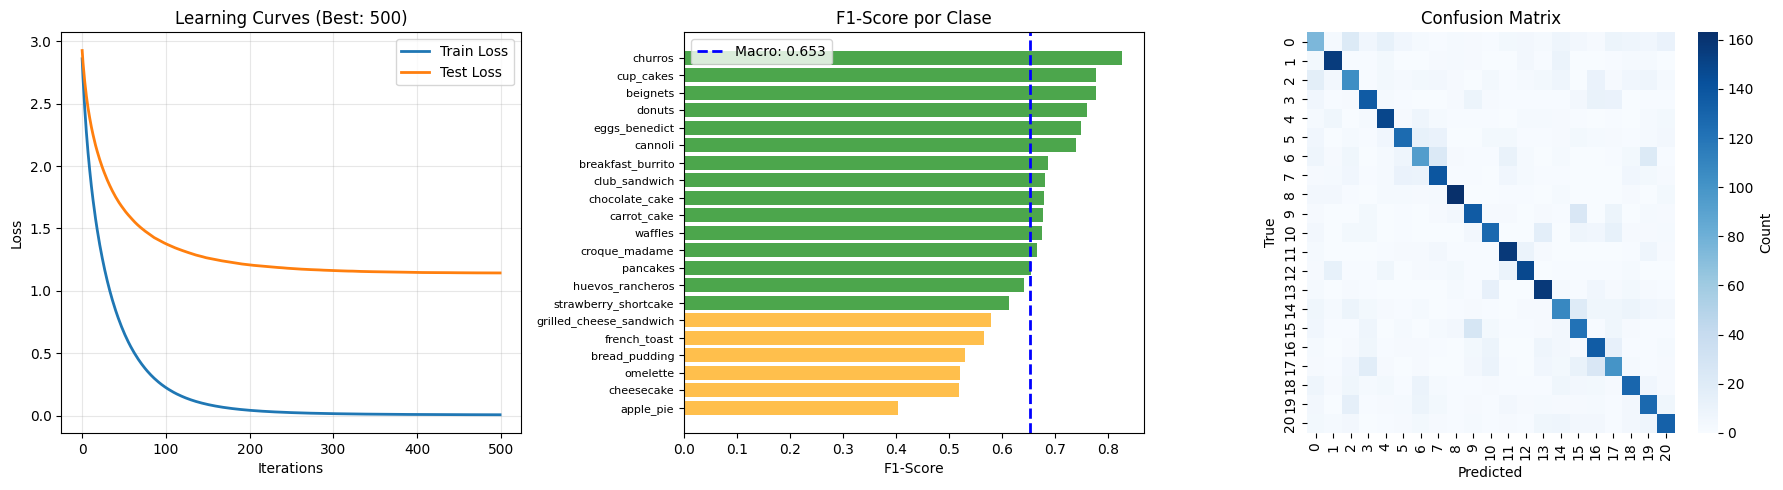

✅ Visualización guardada


In [9]:
# ============================================================================
# 7. VISUALIZACIÓN
# ============================================================================

print("\n[PASO 7] Generando visualizaciones...")
print("-" * 80)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Curvas de aprendizaje
ax1 = axes[0]
train_loss = evals_result['train']['multi_logloss']
test_loss = evals_result['test']['multi_logloss']
ax1.plot(train_loss, label='Train Loss', linewidth=2)
ax1.plot(test_loss, label='Test Loss', linewidth=2)
ax1.set_xlabel('Iterations')
ax1.set_ylabel('Loss')
ax1.set_title(f'Learning Curves (Best: {model.best_iteration})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. F1-Score por clase
ax2 = axes[1]
sorted_idx = np.argsort(f1_per_class)
colors = ['red' if f1 < 0.4 else 'orange' if f1 < 0.6 else 'green' for f1 in f1_per_class[sorted_idx]]
ax2.barh(range(len(DESAYUNO_CLASSES)), f1_per_class[sorted_idx], color=colors, alpha=0.7)
ax2.set_xlabel('F1-Score')
ax2.set_title(f'F1-Score por Clase')
ax2.set_yticks(range(len(DESAYUNO_CLASSES)))
ax2.set_yticklabels([DESAYUNO_CLASSES[i] for i in sorted_idx], fontsize=8)
ax2.axvline(f1_macro, color='blue', linestyle='--', linewidth=2, label=f'Macro: {f1_macro:.3f}')
ax2.legend()

# 3. Matriz de confusión (simplificada)
from sklearn.metrics import confusion_matrix
ax3 = axes[2]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=False, cmap='Blues', ax=ax3, cbar_kws={'label': 'Count'})
ax3.set_xlabel('Predicted')
ax3.set_ylabel('True')
ax3.set_title('Confusion Matrix')

plt.tight_layout()
plt.savefig('/kaggle/working/resultados_finales.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Visualización guardada")

In [10]:
# ============================================================================
# 7B. INFORME DE MÉTRICAS - CLASIFICACIÓN MULTICLASE
# ============================================================================

print("\n" + "="*80)
print("📊 INFORME DE MÉTRICAS DEL MODELO")
print("="*80)

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import pandas as pd

# Asegurar que las predicciones sean etiquetas (no probabilidades)
if y_pred.ndim > 1:
    y_pred_labels = np.argmax(y_pred, axis=1)
else:
    y_pred_labels = y_pred

# --------------------------------------------------------------------------
# 1️⃣ Accuracy global
# --------------------------------------------------------------------------
accuracy = accuracy_score(y_test, y_pred_labels)
print(f"\n✅ Accuracy global: {accuracy:.4f}")

# --------------------------------------------------------------------------
# 2️⃣ Precision, Recall y F1 por clase
# --------------------------------------------------------------------------
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred_labels, average=None
)

print("\n📈 Métricas por clase:")
for i, clase in enumerate(DESAYUNO_CLASSES):
    print(f" - {clase:20s} | Precision: {precision[i]:.3f} | Recall: {recall[i]:.3f} | F1: {f1[i]:.3f}")

f1_macro_local = np.mean(f1)
print(f"\n📊 F1 macro promedio: {f1_macro_local:.3f}")

# --------------------------------------------------------------------------
# 3️⃣ Matriz de confusión
# ---------------------------------------------------------------------



📊 INFORME DE MÉTRICAS DEL MODELO

✅ Accuracy global: 0.6546

📈 Métricas por clase:
 - apple_pie            | Precision: 0.426 | Recall: 0.383 | F1: 0.403
 - beignets             | Precision: 0.760 | Recall: 0.795 | F1: 0.777
 - bread_pudding        | Precision: 0.525 | Recall: 0.533 | F1: 0.529
 - breakfast_burrito    | Precision: 0.680 | Recall: 0.694 | F1: 0.687
 - cannoli              | Precision: 0.716 | Recall: 0.764 | F1: 0.739
 - carrot_cake          | Precision: 0.716 | Recall: 0.643 | F1: 0.677
 - cheesecake           | Precision: 0.560 | Recall: 0.482 | F1: 0.518
 - chocolate_cake       | Precision: 0.662 | Recall: 0.695 | F1: 0.678
 - churros              | Precision: 0.819 | Recall: 0.832 | F1: 0.825
 - club_sandwich        | Precision: 0.667 | Recall: 0.694 | F1: 0.680
 - croque_madame        | Precision: 0.683 | Recall: 0.648 | F1: 0.665
 - cup_cakes            | Precision: 0.755 | Recall: 0.801 | F1: 0.777
 - donuts               | Precision: 0.779 | Recall: 0.740 | F1:

In [11]:
# ============================================================================
# 8. GUARDAR Y DESCARGAR MODELO + VISUALIZACIONES
# ============================================================================

print("\n[PASO 8] Guardando archivos esenciales...")
print("-" * 80)

import pickle
from google.colab import files  # Para descargar en Colab
# Si estás en Kaggle, usa: from IPython.display import FileLink

# ============================================================================
# 1. GUARDAR MODELO PKL
# ============================================================================

print("\n💾 Guardando modelo...")

model_pkl_path = '/kaggle/working/lightgbm_food_model.pkl'
with open(model_pkl_path, 'wb') as f:
    pickle.dump(model, f)

model_size_mb = os.path.getsize(model_pkl_path) / (1024 * 1024)
print(f"✅ Modelo guardado: {model_pkl_path}")
print(f"   • Tamaño: {model_size_mb:.2f} MB")

# ============================================================================
# 2. GUARDAR VISUALIZACIÓN
# ============================================================================

print("\n📊 Guardando visualización...")

viz_path = '/kaggle/working/resultados_finales.png'
# La visualización ya fue guardada en el PASO 7
# Solo verificamos que existe

if os.path.exists(viz_path):
    viz_size_kb = os.path.getsize(viz_path) / 1024
    print(f"✅ Visualización lista: {viz_path}")
    print(f"   • Tamaño: {viz_size_kb:.2f} KB")
else:
    print("⚠️ Visualización no encontrada, regenerando...")
    # Regenerar si no existe
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Curvas de aprendizaje
    ax1 = axes[0]
    train_loss = evals_result['train']['multi_logloss']
    test_loss = evals_result['test']['multi_logloss']
    ax1.plot(train_loss, label='Train Loss', linewidth=2)
    ax1.plot(test_loss, label='Test Loss', linewidth=2)
    ax1.set_xlabel('Iterations')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'Learning Curves (Best: {model.best_iteration})')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. F1-Score por clase
    ax2 = axes[1]
    sorted_idx = np.argsort(f1_per_class)
    colors = ['red' if f1 < 0.4 else 'orange' if f1 < 0.6 else 'green' for f1 in f1_per_class[sorted_idx]]
    ax2.barh(range(len(DESAYUNO_CLASSES)), f1_per_class[sorted_idx], color=colors, alpha=0.7)
    ax2.set_xlabel('F1-Score')
    ax2.set_title(f'F1-Score por Clase')
    ax2.set_yticks(range(len(DESAYUNO_CLASSES)))
    ax2.set_yticklabels([DESAYUNO_CLASSES[i] for i in sorted_idx], fontsize=8)
    ax2.axvline(f1_macro, color='blue', linestyle='--', linewidth=2, label=f'Macro: {f1_macro:.3f}')
    ax2.legend()
    
    # 3. Matriz de confusión
    from sklearn.metrics import confusion_matrix
    ax3 = axes[2]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=False, cmap='Blues', ax=ax3, cbar_kws={'label': 'Count'})
    ax3.set_xlabel('Predicted')
    ax3.set_ylabel('True')
    ax3.set_title('Confusion Matrix')
    
    plt.tight_layout()
    plt.savefig(viz_path, dpi=100, bbox_inches='tight')
    plt.close()
    print(f"✅ Visualización guardada: {viz_path}")





[PASO 8] Guardando archivos esenciales...
--------------------------------------------------------------------------------

💾 Guardando modelo...
✅ Modelo guardado: /kaggle/working/lightgbm_food_model.pkl
   • Tamaño: 43.41 MB

📊 Guardando visualización...
✅ Visualización lista: /kaggle/working/resultados_finales.png
   • Tamaño: 93.28 KB


In [12]:
# ============================================================================
# 9. RESUMEN FINAL
# ============================================================================

print("\n" + "=" * 80)
print("🎉 ENTRENAMIENTO COMPLETADO")
print("=" * 80)

print(f"\n📊 RESUMEN:")
print(f"   • Dataset: {len(DESAYUNO_CLASSES)} clases")
print(f"   • Test samples: {len(y_test):,}")
print(f"   • Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   • F1 Macro: {f1_macro:.4f}")

print(f"\n🏆 MEJOR CLASE: {class_f1_sorted[0][0]} ({class_f1_sorted[0][1]:.3f})")
print(f"⚠️ PEOR CLASE: {class_f1_sorted[-1][0]} ({class_f1_sorted[-1][1]:.3f})")

print(f"\n📦 ARCHIVOS GENERADOS:")
print(f"   ✅ lightgbm_food_model.pkl ({model_size_mb:.2f} MB)")
print(f"   ✅ resultados_finales.png ({os.path.getsize(viz_path)/1024:.2f} KB)")




🎉 ENTRENAMIENTO COMPLETADO

📊 RESUMEN:
   • Dataset: 21 clases
   • Test samples: 4,152
   • Accuracy: 0.6546 (65.46%)
   • F1 Macro: 0.6529

🏆 MEJOR CLASE: churros (0.825)
⚠️ PEOR CLASE: apple_pie (0.403)

📦 ARCHIVOS GENERADOS:
   ✅ lightgbm_food_model.pkl (43.41 MB)
   ✅ resultados_finales.png (93.28 KB)
